<a href="https://colab.research.google.com/github/SAfsana/COVID-19-EDA/blob/main/Copy_of_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sentimentdataset.csv to sentimentdataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("sentimentdataset.csv")

print(df.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

Shape: (732, 15)

Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64

In [ ]:
print(df.isnull().sum())

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [ ]:
df = df[["Text", "Sentiment"]]

print(df.head())

                                                Text    Sentiment
0   Enjoying a beautiful day at the park!        ...   Positive  
1   Traffic was terrible this morning.           ...   Negative  
2   Just finished an amazing workout! 💪          ...   Positive  
3   Excited about the upcoming weekend getaway!  ...   Positive  
4   Trying out a new recipe for dinner tonight.  ...   Neutral   


In [ ]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (732, 2)


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 24
Shape after removing duplicates: (708, 2)


In [ ]:
print(df["Sentiment"].value_counts())

Sentiment
Positive               44
Joy                    42
Excitement             32
Neutral                14
Happy                  14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


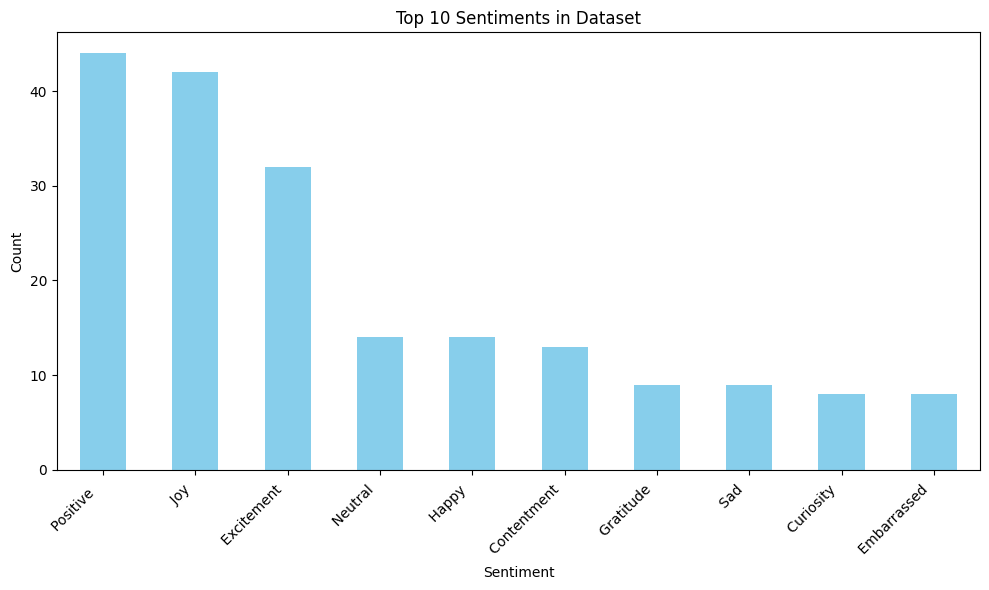

In [ ]:
import matplotlib.pyplot as plt

# Get the top 10 most common sentiments
top_sentiments = df['Sentiment'].value_counts().head(10)

# Create the bar plot
plt.figure(figsize=(10, 6))
top_sentiments.plot(kind='bar', color='skyblue')
plt.title('Top 10 Sentiments in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
X = df["Text"]
y = df["Sentiment"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 566
Testing data: 142


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (566, 2133)
Testing TF-IDF shape: (142, 2133)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred[:20])

Predictions:
[' Positive  ' ' Joy ' ' Positive  ' ' Positive  ' ' Joy ' ' Positive  '
 ' Positive  ' ' Positive  ' ' Positive  ' ' Positive  ' ' Joy ' ' Joy '
 ' Positive  ' ' Positive  ' ' Positive  ' ' Positive  ' ' Excitement '
 ' Positive  ' ' Positive  ' ' Positive  ']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.1056338028169014
Accuracy percentage: 10.56338028169014 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

        Acceptance          0.00      0.00      0.00         1
     Acceptance             0.00      0.00      0.00         2
      Accomplishment        0.00      0.00      0.00         2
        Affection           0.00      0.00      0.00         1
     Ambivalence            0.00      0.00      0.00         1
       Amusement            0.00      0.00      0.00         1
        Anger               0.00      0.00      0.00         1
       Anticipation         0.00      0.00      0.00         1
       Arousal              0.00      0.00      0.00         4
        Awe                 0.00      0.00      0.00         1
                 Bad        0.00      0.00      0.00         1
            Betrayal        0.00      0.00      0.00         1
        Bitter              0.00      0.00      0.00         1
         Bittersweet        0.00      0.00      0.00         1
     Boredom                0.00      0.00      0.00  

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Clean the target variable (remove whitespaces and standardize casing)
df['Sentiment_Cleaned'] = df['Sentiment'].astype(str).str.strip().str.title()

# Filter out extremely rare sentiments to stabilize evaluation
sentiment_counts = df['Sentiment_Cleaned'].value_counts()
valid_sentiments = sentiment_counts[sentiment_counts >= 3].index
df_filtered = df[df['Sentiment_Cleaned'].isin(valid_sentiments)]

X_clean = df_filtered['Text']
y_clean = df_filtered['Sentiment_Cleaned']

# Re-split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Re-vectorize
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Retrain model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = model.predict(X_test_tfidf)
print("New Accuracy:", accuracy_score(y_test, y_pred))
print("\nUpdated Classification Report (for sentiments with >=3 samples):")
print(classification_report(y_test, y_pred, zero_division=0))

New Accuracy: 0.23893805309734514

Updated Classification Report (for sentiments with >=3 samples):
                precision    recall  f1-score   support

    Acceptance       1.00      1.00      1.00         2
Accomplishment       0.00      0.00      0.00         1
    Admiration       0.00      0.00      0.00         1
     Adventure       0.00      0.00      0.00         1
   Ambivalence       1.00      1.00      1.00         1
     Amusement       0.00      0.00      0.00         1
       Arousal       0.00      0.00      0.00         1
           Awe       0.00      0.00      0.00         2
           Bad       0.00      0.00      0.00         1
      Betrayal       0.00      0.00      0.00         1
    Bitterness       0.00      0.00      0.00         1
       Boredom       0.00      0.00      0.00         1
      Calmness       0.00      0.00      0.00         1
    Compassion       0.00      0.00      0.00         1
     Confusion       0.00      0.00      0.00         2
   

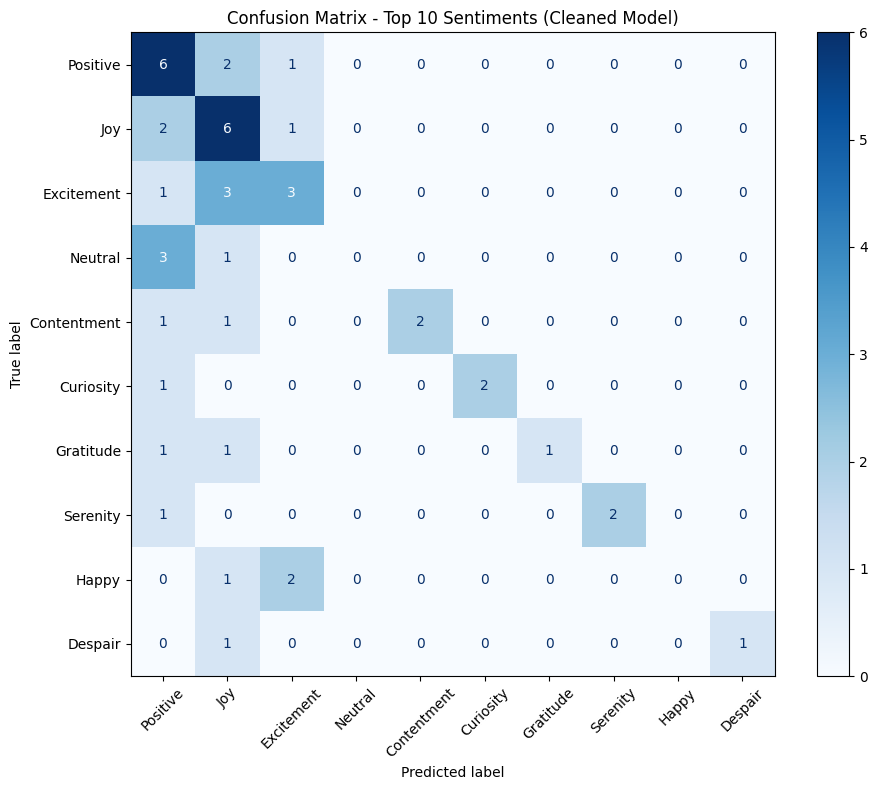

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Identify top 10 labels by frequency in the test set
top_labels = y_test.value_counts().head(10).index.tolist()

# Filter predictions and actual targets to only include these top labels
mask = y_test.isin(top_labels) & np.isin(y_pred, top_labels)
y_test_filtered = y_test[mask]
y_pred_filtered = y_pred[mask]

# Compute and display confusion matrix
cm = confusion_matrix(y_test_filtered, y_pred_filtered, labels=top_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Top 10 Sentiments (Cleaned Model)")
plt.tight_layout()
plt.show()

In [ ]:
new_text = ["I really enjoyed this product"]

new_text_tfidf = vectorizer.transform(new_text)

prediction = model.predict(new_text_tfidf)

print("Text:", new_text[0])
print("Predicted Sentiment:", prediction[0])

Text: I really enjoyed this product
Predicted Sentiment: Positive
